<div style="width:100%">

<div style="width:50%; height:100% ; display:flex; align-items:center; justify-content:center; margin:auto;">
<h1>  Possum Regresssion Model 🐼</h1>
</div>

</div>

# 📚 Import Basics Libraries

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
import pickle
from sklearn.preprocessing import StandardScaler , OneHotEncoder

################################################

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer


# 👁️ Reading Dataset

In [18]:
data = pd.read_csv("possum.csv")
df = data.copy()
df.head()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


# 📋 General Information 

In [19]:
print(f'📊 Data Shape: {df.shape}')

📊 Data Shape: (104, 14)


In [20]:
print(f'📊 Number of rows: {df.shape[0]}')
print(f'📊 Number of columns: {df.shape[1]}')

📊 Number of rows: 104
📊 Number of columns: 14


In [21]:
print('Dataset Information:')
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      104 non-null    int64  
 1   site      104 non-null    int64  
 2   Pop       104 non-null    object 
 3   sex       104 non-null    object 
 4   age       102 non-null    float64
 5   hdlngth   104 non-null    float64
 6   skullw    104 non-null    float64
 7   totlngth  104 non-null    float64
 8   taill     104 non-null    float64
 9   footlgth  103 non-null    float64
 10  earconch  104 non-null    float64
 11  eye       104 non-null    float64
 12  chest     104 non-null    float64
 13  belly     104 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.5+ KB


# 🧹 Data Cleaning & Preprocessing

In [22]:
average = df['age'].mean(numeric_only=True)
df['age'] = df['age'].fillna(average)

In [23]:
average2 = df['footlgth'].mean(numeric_only=True)
df['footlgth'] = df['footlgth'].fillna(average2)

In [24]:
print('Dataset Information:')
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      104 non-null    int64  
 1   site      104 non-null    int64  
 2   Pop       104 non-null    object 
 3   sex       104 non-null    object 
 4   age       104 non-null    float64
 5   hdlngth   104 non-null    float64
 6   skullw    104 non-null    float64
 7   totlngth  104 non-null    float64
 8   taill     104 non-null    float64
 9   footlgth  104 non-null    float64
 10  earconch  104 non-null    float64
 11  eye       104 non-null    float64
 12  chest     104 non-null    float64
 13  belly     104 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.5+ KB


# 🎯 Exploratory Data Analysis

C:\Users\COMPUMART\AppData\Local\Temp\ipykernel_7376\1515512729.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_corr.values, y=age_corr.index, palette='coolwarm')


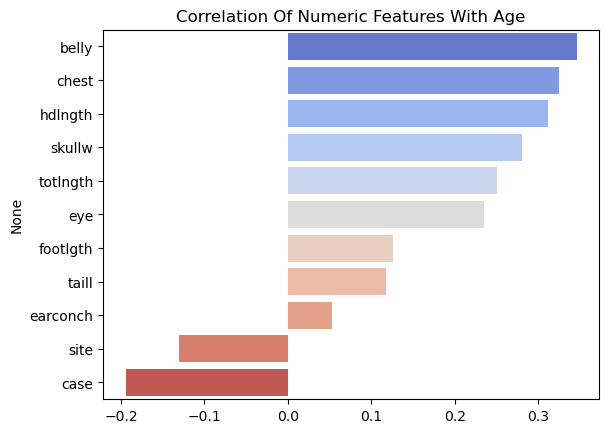

In [40]:
correlation_matrix = df.corr(numeric_only=True)
age_corr = correlation_matrix['age'].sort_values(ascending=False)
age_corr = age_corr.drop('age')

plt.figure()
sns.barplot(x=age_corr.values, y=age_corr.index, palette='coolwarm')

plt.title("Correlation Of Numeric Features With Age")
plt.show()

C:\Users\COMPUMART\AppData\Local\Temp\ipykernel_7376\2349675626.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='sex', y='age', data=df, palette='Set2')
C:\Users\COMPUMART\AppData\Local\Temp\ipykernel_7376\2349675626.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='Pop', y='age', data=df, palette='Pastel1')


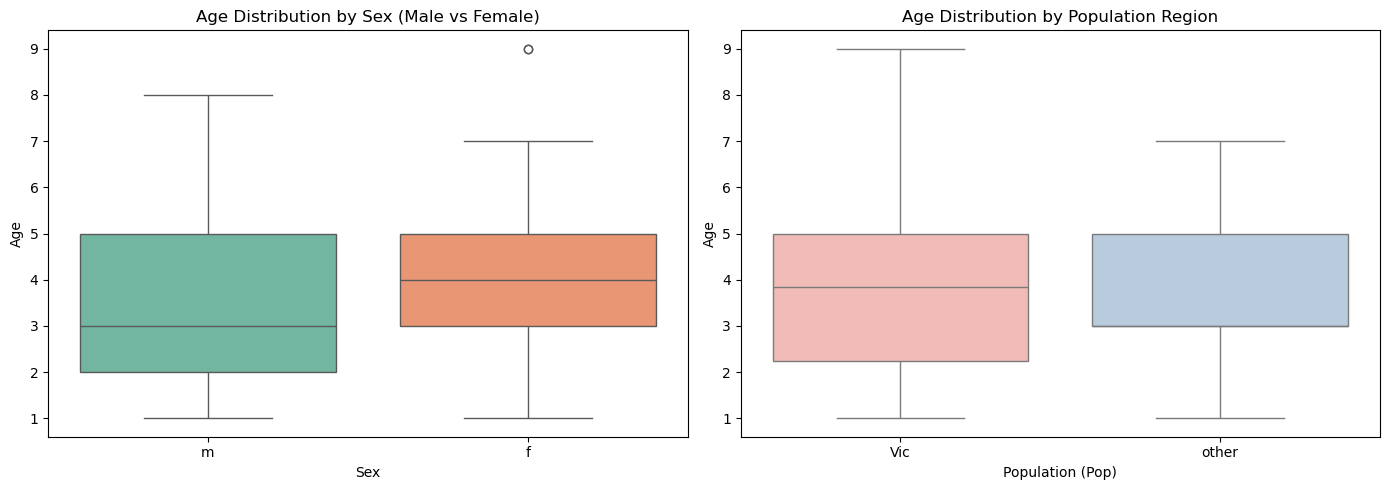

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(ax=axes[0], x='sex', y='age', data=df, palette='Set2')
axes[0].set_title('Age Distribution by Sex (Male vs Female)')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Age')

sns.boxplot(ax=axes[1], x='Pop', y='age', data=df, palette='Pastel1')
axes[1].set_title('Age Distribution by Population Region')
axes[1].set_xlabel('Population (Pop)')
axes[1].set_ylabel('Age')

plt.tight_layout() 
plt.show()

# 🪓 Split Features & Target

In [55]:
X = df.drop(columns=['age' , 'case' , 'site' , 'earconch' , 'footlgth' , 'eye' , 'Pop'])

y = df['age']

# 🪓 Split Train & Test

In [56]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

# 🤖 Pipeline

In [75]:
numeric = ['hdlngth','skullw' , 'totlngth' , 'taill' , 'chest' , 'belly']
categorical = ['sex']

preprocessor = ColumnTransformer(
    transformers = [
        ('num' , StandardScaler() , numeric),
        ('cat' , OneHotEncoder(drop='first') , categorical)
        ]
)

pipeline = Pipeline(steps=[
    ('preprocessor' , preprocessor),
    ('model' , KNeighborsRegressor())
])

# 🎯 Hyperparameter Tuning

In [80]:
param_grid = {
    "model__n_neighbors" : [3 ,5 ,7 ,9 ,11,13,15],
    "model__weights" : ["uniform","distance"],
    "model__metric" : ["euclidean","manhattan"],
}

grid = GridSearchCV (
    pipeline , 
    param_grid,
    cv=5 , 
    scoring = "r2",
    n_jobs= -1
)
grid.fit(X_train , y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [3, 5, ...], 'model__weights': ['uniform', 'distance']}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


# 💯 Best Model

In [81]:
print("Best Params :" , grid.best_params_)
best_model = grid.best_estimator_

Best Params : {'model__metric': 'euclidean', 'model__n_neighbors': 13, 'model__weights': 'distance'}


# 🤖 Prediction

In [83]:
y_pred = best_model.predict(X_test)

# 🏹 Evaluation

In [84]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.14652161564693744


# 🖥️ Prediction Function

In [94]:
def predict_animal_age(hdlngth, skullw, totlngth, taill, chest, belly, sex):

    input_dict = {
        'hdlngth': [hdlngth],
        'skullw': [skullw],
        'totlngth': [totlngth],
        'taill': [taill],
        'chest': [chest],
        'belly': [belly],
        'sex': [sex]
    }
    
    input_df = pd.DataFrame(input_dict)
    prediction = best_model.predict(input_df)
    predicted_age = prediction[0]
    
    return f"Expected Age: {predicted_age:.1f} Years"

In [95]:
result = predict_animal_age(hdlngth=94.1, skullw=60.0, totlngth=89.0, taill=36.0, chest=28.5, belly=33.0, sex='m')
print(result)

Expected Age: 4.5 Years


# 💾 Save Model

In [96]:
with open('animal_age_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)